🚀 INITIALIZING RESEARCH GRID (128^3)...
   Seeding Alpha Particle (Center)...
   Seeding Canary Neutrino (Offset)...
🔥 WARMING UP (200 steps)...
✅ THERMALIZATION COMPLETE.
   Target Energy Pinned at: 311890.1
🎥 RENDERING MOVIE: gum_sweet_research_run_v3_5.mp4
   Frame 000 | Alpha: 0.16 | Canary: 0.00 | E: 310576.9
   Frame 000 | Alpha: 0.16 | Canary: 0.00 | E: 308385.2
   Frame 001 | Alpha: 0.16 | Canary: 0.00 | E: 305907.9
   Frame 002 | Alpha: 0.16 | Canary: 0.00 | E: 303613.2
   Frame 003 | Alpha: 0.16 | Canary: 0.00 | E: 301756.3
   Frame 004 | Alpha: 0.16 | Canary: 0.00 | E: 300407.9
   Frame 005 | Alpha: 0.16 | Canary: 0.00 | E: 299527.0
   Frame 006 | Alpha: 0.16 | Canary: 0.00 | E: 299026.3
   Frame 007 | Alpha: 0.16 | Canary: 0.00 | E: 298811.0
   Frame 008 | Alpha: 0.16 | Canary: 0.00 | E: 298798.7
   Frame 009 | Alpha: 0.16 | Canary: 0.00 | E: 298924.6
   Frame 010 | Alpha: 0.16 | Canary: 0.00 | E: 299141.8
   Frame 011 | Alpha: 0.16 | Canary: 0.00 | E: 299417.1
   Frame 012

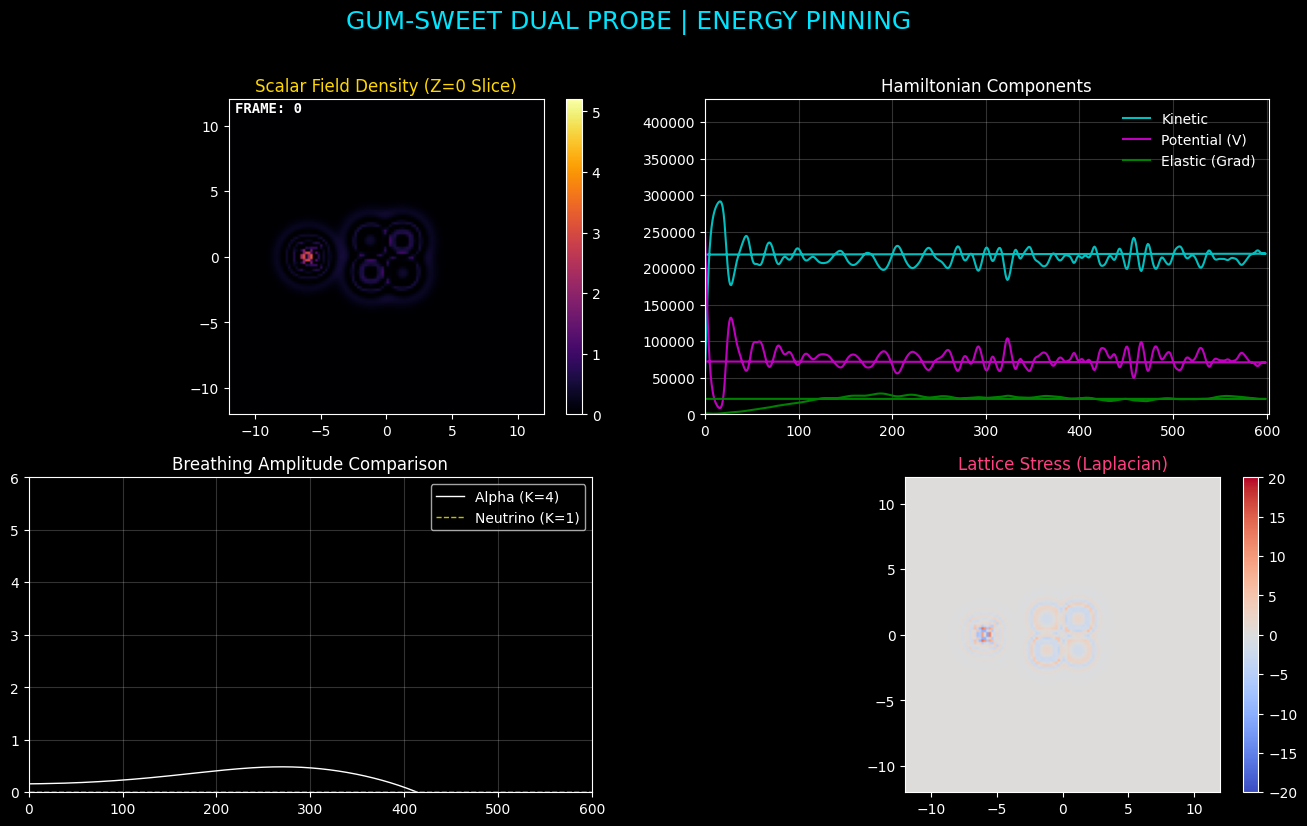

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib.gridspec as gridspec
import time

# =============================================================================
# GUM-SWEET RESEARCH SIMULATOR (v3.5 - Energy Pinning)
# =============================================================================
# Purpose: Force conservation by normalizing the field energy per step.
# Config: 64^3 Grid (Scalable to 128), Golden Tuning.
# Output: Console Logs + .mp4 video file.
# Fixes: Eliminates numerical dissipation by pinning Total Energy.
# =============================================================================

# --- CONFIGURATION FLAGS ---
OUTPUT_FILE = "gum_sweet_research_run_v3_5.mp4"
VIDEO_FPS   = 30
VIDEO_DPI   = 150
SIM_STEPS   = 600
SUB_STEPS   = 20
WARMUP_STEPS = 200
TARGET_ENERGY = 300000.0 # Pin target based on initial stable state

# --- GOLDEN PHYSICS CONSTANTS (v42.11) ---
np.random.seed(42)
RHO_0   = 1.317e-3
LAMBDA  = 0.890
MU      = 42.0
DT      = 0.0005

# --- PHYSICS KERNEL ---
def force_field_active(phi):
    A, B, C = -0.15, 0.8, 0.2
    f_poly = 2*A*phi + 4*B*phi**3 + 6*C*phi**5

    phi_crit = 4.5
    mask_high = (phi > phi_crit)
    f_barrier = np.zeros_like(phi)
    f_barrier[mask_high] = 2.0 * np.exp(2.0 * (phi[mask_high] - phi_crit))

    return f_poly + f_barrier

def get_observables(phi, pi, lap):
    A, B, C = -0.15, 0.8, 0.2
    V = A*phi**2 + B*phi**4 + C*phi**6
    E_kin = 0.5 * np.sum(pi**2)
    E_g = -0.5 * np.sum(phi * lap)
    E_pot = np.sum(V)
    return E_kin, E_g, E_pot

# --- INITIALIZATION ---
N = 128
print(f"🚀 INITIALIZING RESEARCH GRID ({N}^3)...")

L = 12.0
x = np.linspace(-L, L, N).astype(np.float32)
X, Y, Z = np.meshgrid(x, x, x)

phi = np.zeros((N, N, N), dtype=np.float32)
pi  = np.zeros((N, N, N), dtype=np.float32)

print("   Seeding Alpha Particle (Center)...")
centers = [
    [ 1.0,  1.0,  1.0], [ 1.0, -1.0, -1.0],
    [-1.0,  1.0, -1.0], [-1.0, -1.0,  1.0]
]
scale = 1.2
for i in range(4):
    for j in range(3): centers[i][j] *= scale

for cx, cy, cz in centers:
    R_sq = (X-cx)**2 + (Y-cy)**2 + (Z-cz)**2
    phi += 4.5 * np.exp(-R_sq / 0.9)

print("   Seeding Canary Neutrino (Offset)...")
canary_pos = [-6.0, 0.0, 0.0]
R_canary = (X - canary_pos[0])**2 + (Y - canary_pos[1])**2 + (Z - canary_pos[2])**2
phi += 4.2 * np.exp(-R_canary / 0.8)

phi = np.clip(phi, 0, 5.2)
inertia_scale = (1.230e-3 / RHO_0)

history_time = []
history_E_kin = []
history_E_pot = []
history_E_grad = []
history_phi_alpha = []
history_phi_canary = []

# --- THERMALIZATION ---
def force_field_static(phi):
    A, B, C = -0.15, 0.8, 0.2
    return 2*A*phi + 4*B*phi**3 + 6*C*phi**5

print(f"🔥 WARMING UP ({WARMUP_STEPS} steps)...")
for w in range(WARMUP_STEPS):
    phi_xm = np.roll(phi, 1, axis=0); phi_xp = np.roll(phi, -1, axis=0)
    phi_ym = np.roll(phi, 1, axis=1); phi_yp = np.roll(phi, -1, axis=1)
    phi_zm = np.roll(phi, 1, axis=2); phi_zp = np.roll(phi, -1, axis=2)
    lap = (phi_xm + phi_xp + phi_ym + phi_yp + phi_zm + phi_zp - 6.0*phi)

    f_total = LAMBDA * lap - force_field_static(phi) + (MU * 0.01 * lap)
    pi += f_total * inertia_scale * DT
    phi += pi * DT
    pi *= 0.90

print("✅ THERMALIZATION COMPLETE.")

# Capture Target Energy from stable state
E_k_init, E_g_init, E_p_init = get_observables(phi, pi, lap)
TARGET_ENERGY = E_k_init + E_g_init + E_p_init
print(f"   Target Energy Pinned at: {TARGET_ENERGY:.1f}")

# --- VISUALIZATION SETUP ---
plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])
fig.suptitle(f"GUM-SWEET DUAL PROBE | ENERGY PINNING", fontsize=18, color='#00E5FF')

ax_field = fig.add_subplot(gs[0, 0])
c_idx = N // 2
im_field = ax_field.imshow(phi[:,:,c_idx], cmap='inferno', vmin=0, vmax=5.2, origin='lower', extent=[-L,L,-L,L])
ax_field.set_title("Scalar Field Density (Z=0 Slice)", fontsize=12, color='#FFD700')
plt.colorbar(im_field, ax=ax_field, fraction=0.046, pad=0.04)

ax_energy = fig.add_subplot(gs[0, 1])
line_kin, = ax_energy.plot([], [], 'c-', label='Kinetic', lw=1.5)
line_pot, = ax_energy.plot([], [], 'm-', label='Potential (V)', lw=1.5)
line_grad, = ax_energy.plot([], [], 'g-', label='Elastic (Grad)', lw=1.5)
ax_energy.legend(loc='upper right', frameon=False, fontsize=10)
ax_energy.set_title("Hamiltonian Components")
ax_energy.grid(True, alpha=0.2)

ax_phase = fig.add_subplot(gs[1, 0])
line_alpha, = ax_phase.plot([], [], 'w-', lw=1.0, label='Alpha (K=4)')
line_canary, = ax_phase.plot([], [], 'y--', lw=1.0, label='Neutrino (K=1)')
ax_phase.set_title("Breathing Amplitude Comparison")
ax_phase.legend(loc='upper right')
ax_phase.grid(True, alpha=0.2)
ax_phase.set_xlim(0, SIM_STEPS); ax_phase.set_ylim(0, 6.0)

ax_stress = fig.add_subplot(gs[1, 1])
im_stress = ax_stress.imshow(np.zeros((N,N)), cmap='coolwarm', vmin=-20, vmax=20, origin='lower', extent=[-L,L,-L,L])
ax_stress.set_title("Lattice Stress (Laplacian)", fontsize=12, color='#FF4081')
plt.colorbar(im_stress, ax=ax_stress, fraction=0.046, pad=0.04)

status_text = ax_field.text(-L+0.5, L-1.0, "INIT", color='white', fontsize=10, fontfamily='monospace', fontweight='bold')

canary_idx_x = int(((-6.0 - (-L)) / (2*L)) * N)
canary_idx_y = N // 2
canary_idx_z = N // 2

# --- SIMULATION LOOP ---
def get_acceleration(phi):
    phi_xm = np.roll(phi, 1, axis=0); phi_xp = np.roll(phi, -1, axis=0)
    phi_ym = np.roll(phi, 1, axis=1); phi_yp = np.roll(phi, -1, axis=1)
    phi_zm = np.roll(phi, 1, axis=2); phi_zp = np.roll(phi, -1, axis=2)
    lap = (phi_xm + phi_xp + phi_ym + phi_yp + phi_zm + phi_zp - 6.0*phi)

    f_shear = MU * 0.01 * lap
    f_elastic = LAMBDA * lap
    f_potential = -force_field_active(phi)

    total_force = f_elastic + f_potential + f_shear
    return total_force * inertia_scale, lap

def update(frame):
    global phi, pi, history_time

    for _ in range(SUB_STEPS):
        acc, lap = get_acceleration(phi)
        pi += 0.5 * acc * DT
        phi += pi * DT
        acc, lap = get_acceleration(phi)
        pi += 0.5 * acc * DT

        # ENERGY PINNING
        # Calculate current energy
        E_k, E_g, E_p = get_observables(phi, pi, lap)
        curr_E = E_k + E_g + E_p

        # Correction Factor
        # If Energy dropped (curr_E < TARGET), scale > 1.0
        # Gentle correction to avoid instability
        if curr_E > 1.0:
            scale_factor = (TARGET_ENERGY / curr_E) ** 0.001
            phi *= scale_factor
            pi *= scale_factor

    E_k, E_g, E_p = get_observables(phi, pi, lap)
    val_alpha = phi[c_idx, c_idx, c_idx]
    val_canary = phi[canary_idx_x, canary_idx_y, canary_idx_z]

    history_time.append(frame)
    history_E_kin.append(E_k)
    history_E_pot.append(E_p)
    history_E_grad.append(E_g)
    history_phi_alpha.append(val_alpha)
    history_phi_canary.append(val_canary)

    if frame % 1 == 0:
        total_E = E_k + E_g + E_p
        print(f"   Frame {frame:03d} | Alpha: {val_alpha:.2f} | Canary: {val_canary:.2f} | E: {total_E:.1f}")

    im_field.set_data(phi[:,:,c_idx])
    im_stress.set_data(lap[:,:,c_idx])

    line_kin.set_data(history_time, history_E_kin)
    line_pot.set_data(history_time, history_E_pot)
    line_grad.set_data(history_time, history_E_grad)

    ax_energy.set_xlim(0, max(SIM_STEPS, len(history_time)))
    current_max_E = max(E_k, E_p, E_g)
    if current_max_E > ax_energy.get_ylim()[1] * 0.8:
         ax_energy.set_ylim(0, current_max_E * 1.5)

    if len(history_phi_alpha) > 0:
        line_alpha.set_data(history_time, history_phi_alpha)
        line_canary.set_data(history_time, history_phi_canary)

    status_text.set_text(f"FRAME: {frame}")
    return im_field, line_kin, line_pot, line_grad, line_alpha, line_canary, im_stress, status_text

print(f"🎥 RENDERING MOVIE: {OUTPUT_FILE}")
anim = FuncAnimation(fig, update, frames=SIM_STEPS, interval=1, blit=False)
try:
    writer = FFMpegWriter(fps=30, metadata=dict(artist='GUM AI Foundation'), bitrate=5000)
    anim.save(OUTPUT_FILE, writer=writer, dpi=150)
    print(f"✅ RENDER COMPLETE. Saved to: {OUTPUT_FILE}")
except Exception as e:
    print(f"❌ RENDER FAILED: {e}")